In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

from tensorflow.keras import layers, Model
from tensorflow.keras.applications import ResNet50, EfficientNetB0
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

from sklearn.metrics import confusion_matrix, classification_report

In [4]:
DATASET_PATH = "/content/drive/MyDrive/AneN_Dasaset"
WORK_DIR = "/content/AneN_Dasaset"

os.makedirs(WORK_DIR, exist_ok=True)

classes = ["Anemic_individuals", "Healthy_individuals"]

In [5]:
IMG_SIZE = (224,224)
BATCH_SIZE = 16

train_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

classes = train_ds.class_names
print("Classes:", classes)

Found 2000 files belonging to 2 classes.
Using 1600 files for training.
Found 2000 files belonging to 2 classes.
Using 400 files for validation.
Classes: ['Anemic_individuals', 'Healthy_individuals']


In [7]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

In [8]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

In [9]:
input_layer = layers.Input(shape=(224,224,3))

x = data_augmentation(input_layer)

resnet = ResNet50(
    include_top=False,
    weights="imagenet",
    input_tensor=x
)

effnet = EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_tensor=x
)

for layer in resnet.layers:
    layer.trainable = False

for layer in effnet.layers:
    layer.trainable = False

r = layers.GlobalAveragePooling2D()(resnet.output)
e = layers.GlobalAveragePooling2D()(effnet.output)

merged = layers.Concatenate()([r,e])

x = layers.BatchNormalization()(merged)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.5)(x)

output = layers.Dense(1, activation="sigmoid")(x)

model = Model(inputs=input_layer, outputs=output)

model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential          │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ sequential[0][0]  │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati

 Total params: 28,503,076 (108.73 MB)

 Trainable params: 859,137 (3.28 MB)

 Non-trainable params: 27,643,939 (105.45 MB)

In [10]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [11]:
callbacks = [

    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=3
    ),

    ModelCheckpoint(
        "best_model.h5",
        monitor="val_accuracy",
        save_best_only=True
    )
]

In [12]:
EPOCHS = 25

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/25
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - accuracy: 0.5909 - loss: 0.8313

100/100 ━━━━━━━━━━━━━━━━━━━━ 681s 1s/step - accuracy: 0.5914 - loss: 0.8302 - val_accuracy: 0.7000 - val_loss: 0.5764 - learning_rate: 1.0000e-04
Epoch 2/25
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - accuracy: 0.7158 - loss: 0.5868

100/100 ━━━━━━━━━━━━━━━━━━━━ 31s 165ms/step - accuracy: 0.7159 - loss: 0.5867 - val_accuracy: 0.7600 - val_loss: 0.5245 - learning_rate: 1.0000e-04
Epoch 3/25
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - accuracy: 0.7667 - loss: 0.5060

100/100 ━━━━━━━━━━━━━━━━━━━━ 32s 176ms/step - accuracy: 0.7666 - loss: 0.5061 - val_accuracy: 0.7650 - val_loss: 0.4743 - learning_rate: 1.0000e-04
Epoch 4/25
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - accuracy: 0.7759 - loss: 0.4694

100/100 ━━━━━━━━━━━━━━━━━━━━ 31s 159ms/step - accuracy: 0.7757 - loss: 0.4699 - val_accuracy: 0.7725 - val_loss: 0.4879 - learning_rate: 1.0000e-04
Epoch 5/25
100/100 ━━━━━━━━━━━━━━━━━━━━ 31s 165ms/step - accuracy: 0.7932 - loss: 0.4593 - val_accuracy: 0.7500 - val_loss: 0.4759 - learning_rate: 1.0000e-04
Epoch 6/25
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - accuracy: 0.7529 - loss: 0.4816

100/100 ━━━━━━━━━━━━━━━━━━━━ 37s 226ms/step - accuracy: 0.7530 - loss: 0.4815 - val_accuracy: 0.7825 - val_loss: 0.4488 - learning_rate: 1.0000e-04
Epoch 7/25
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - accuracy: 0.7886 - loss: 0.4392

100/100 ━━━━━━━━━━━━━━━━━━━━ 31s 160ms/step - accuracy: 0.7884 - loss: 0.4393 - val_accuracy: 0.7950 - val_loss: 0.4507 - learning_rate: 1.0000e-04
Epoch 8/25
100/100 ━━━━━━━━━━━━━━━━━━━━ 39s 152ms/step - accuracy: 0.7913 - loss: 0.4531 - val_accuracy: 0.7775 - val_loss: 0.4779 - learning_rate: 1.0000e-04
Epoch 9/25
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - accuracy: 0.7779 - loss: 0.4452

100/100 ━━━━━━━━━━━━━━━━━━━━ 32s 173ms/step - accuracy: 0.7779 - loss: 0.4451 - val_accuracy: 0.8025 - val_loss: 0.4610 - learning_rate: 1.0000e-04
Epoch 10/25
100/100 ━━━━━━━━━━━━━━━━━━━━ 39s 150ms/step - accuracy: 0.7958 - loss: 0.4212 - val_accuracy: 0.7875 - val_loss: 0.4627 - learning_rate: 3.0000e-05
Epoch 11/25
100/100 ━━━━━━━━━━━━━━━━━━━━ 30s 153ms/step - accuracy: 0.8031 - loss: 0.4169 - val_accuracy: 0.7750 - val_loss: 0.4761 - learning_rate: 3.0000e-05


<Figure size 800x500 with 0 Axes>

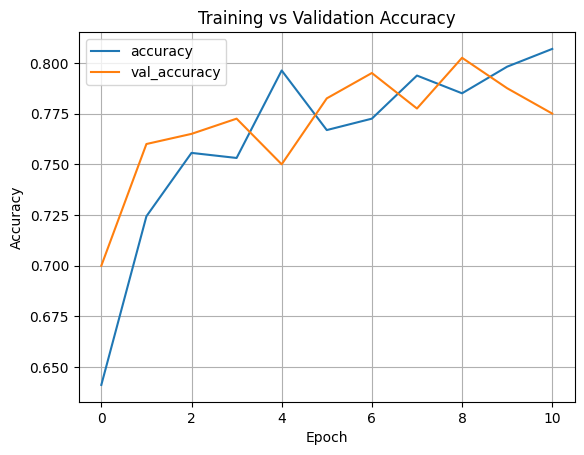

<Figure size 800x500 with 0 Axes>

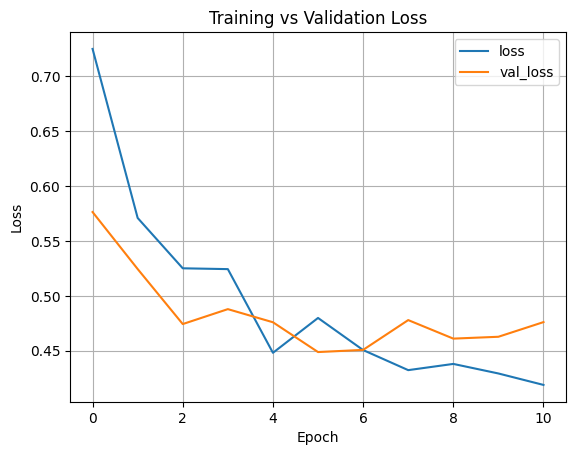

In [13]:
history_df = pd.DataFrame(history.history)

plt.figure(figsize=(8,5))
history_df[['accuracy','val_accuracy']].plot()
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

plt.figure(figsize=(8,5))
history_df[['loss','val_loss']].plot()
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

In [14]:
y_true = []
y_hat = []

for images, labels in val_ds:

    preds = model.predict(images)

    preds = (preds > 0.5).astype("int32")

    y_true.extend(labels.numpy())
    y_hat.extend(preds.flatten())

y_true = np.array(y_true)
y_hat = np.array(y_hat)

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 222ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 241ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 258ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 245ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 268ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step


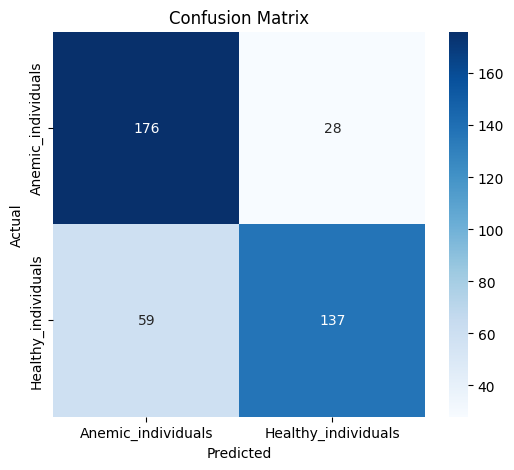

In [15]:
cm = confusion_matrix(y_true,y_hat)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap="Blues",
    xticklabels=classes,
    yticklabels=classes
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [16]:
print(classification_report(y_true,y_hat,target_names=classes))

                     precision    recall  f1-score   support

 Anemic_individuals       0.75      0.86      0.80       204
Healthy_individuals       0.83      0.70      0.76       196

           accuracy                           0.78       400
          macro avg       0.79      0.78      0.78       400
       weighted avg       0.79      0.78      0.78       400



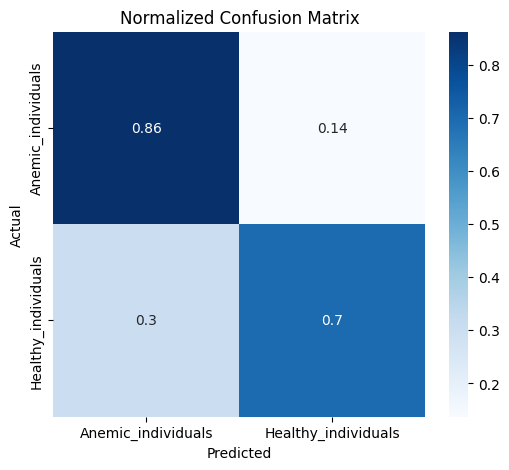

In [17]:
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_norm,
    annot=True,
    cmap="Blues",
    xticklabels=classes,
    yticklabels=classes
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Normalized Confusion Matrix")

plt.show()

In [18]:
IN_COLAB = True
# 8. Save model
save_path = "/content/drive/MyDrive/New folder/Hybrid_Model_1(ResNet + EfficientNet).keras" if IN_COLAB else "./anemia_model_cnn_vit.keras"
model.save(save_path)
print("Model saved to:", save_path)

Model saved to: /content/drive/MyDrive/New folder/Hybrid_Model_1(ResNet + EfficientNet).keras
